
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd

In [3]:
medical_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/medical-charges (2).csv')

In [4]:
medical_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Ідеї для вирішення задачі:
1. Проаналізувати кореляцію між параметрами (вік, стать, ІМТ, і тд) (наприклад, за допомогою heatmap) та первинно визначити, які фактори найбільше корелюють з розміром внеску. На основі отриманої інформації відсіяти метрики, які мало впливають на ціну та дослідити, що впливає найбільше. Можна спробувати скласти таблицю для 2-3 основних метрик, за якою буде визначатися орієнтовне значення `charges`.
2. Виокремити основні тарифи для курців/некурців та визначити для них вартість, яка відповідатиме медіані або середньому для відповідних даних з вибірки
3. До попереднього варіанту додати також групування за регіоном, тож на кожен регіон буде по 2 тарифи
4. Додати до попереднього діапазон ІМТ, збільшивши кількість тарифів.
В результаті отримається багаторівнева вкладена структура


**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [26]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [6]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['grey', 'blue'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
medical_df[medical_df['smoker'] == "yes"]['charges'].describe()

,charges
count,274.000000
mean,32050.231832
std,11541.547176
min,12829.455100
25%,20826.244213
50%,34456.348450
75%,41019.207275
max,63770.428010



- Медіана виплат для чоловіків та жінок практично співпадає, проте q3 для чоловіків значно більше, ніж для жінок. Окрім того, у виплатах більше $30,000 переважають чоловіки.Можливо, це пов'язано або з більшою схильністю до хвороб та страхових випадків саме для чоловіків.
- Для нижчих медичних витрат (2,000 - 28,000) співвідношення кількості чоловіків та жінок майже рівні, більша відмінність з'являється для більших витрат.

In [7]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

- Медіани витрат для всіх регіонів близькі (9,000 - 10,000), проте значна різниця спостергіється у q3. Для регіону southeast найбільше значення для q3, отже більше виплат у сумах 16,000 - 19,000. Тобто можна сказати, що для регіону southeast та northeast розміри виплат можуть бути більшими, проте, відповідно до візуалізації, це не є чіткою закономірністю.
- Розподіл витрат від $14,000 загалом не має явних відмінностей для різних регіонів, викиди містяться у всіх регіонах без різких відмінностей.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [12]:
fig = px.histogram(medical_df,
                   x='region',
                   color='smoker',
                   title='Region')
fig.update_layout(bargap=0.1)
fig.show()

- для всіх регіонів співвідношення курців та некурців мають приблизно однакове співвідношення
- у всіх регіонах переважна кількість клієнтів є курцями
- southeast загалом має більшу кількість клієнтів, тому, відповідно, для нього більша кількість курців та некурців порівняно з іншими регіонами

In [13]:
fig = px.histogram(medical_df,
                   x='children',
                   color='smoker',
                   title='Children')
fig.update_layout(bargap=0.1)
fig.show()

- більшість клієнтів не мають дітей або не вказали їх кількість
- серед клієнтів з 1-3 дітьми кількість курців приблизно однакова
- серед клієнтів з 4-5 дітьми дуже мало записів, тому найменше курців

Швидше за все, кількість дітей майже не впливає на факт наявності шкідливої звички.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [14]:
fig = px.violin(medical_df,
                 x='children',
                 y='charges',
                 title='Children vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

- розподіл розмір виплат загалом виглядає однаково для різної кількості дітей у клієнтів. Для 5 дітей ширина розподілу найбільша, проте даних для таких клієнтів найменше.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [15]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

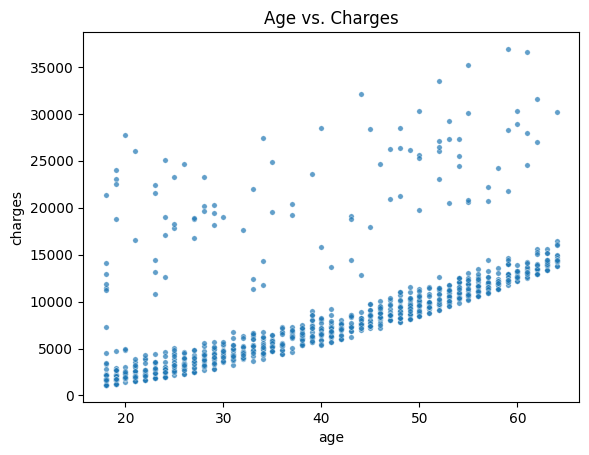

In [18]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15);

In [16]:
def estimate_charges(age, w, b):
    return w * age + b

In [17]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

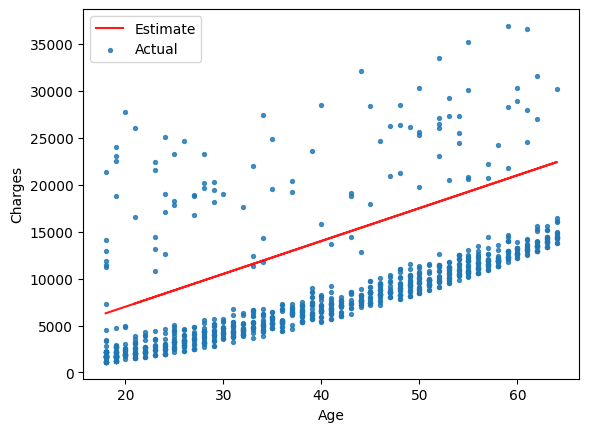

In [20]:
try_parameters(non_smoker_df, 350, 0)

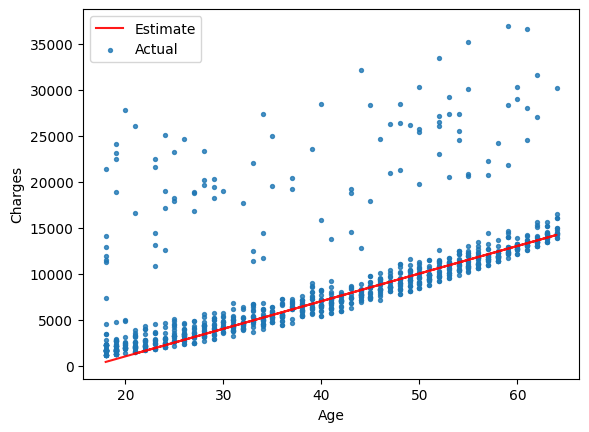

In [21]:
try_parameters(non_smoker_df, 300, -5000)

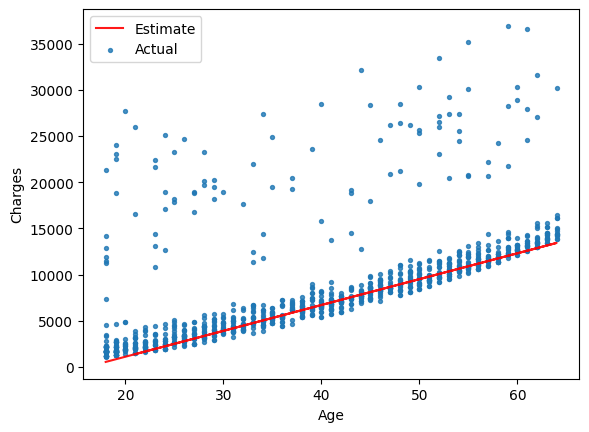

In [22]:
try_parameters(non_smoker_df, 280, -4500)

Для швидшого підбору потрібно враховувати масштаб даних, а також те, що параметр b відповідає за висоту лінії на осі y, а коефіцієнт біля точок вхідних даних коригує кут нахилу прямої.
Чим ближче наближення до реальних даних, тим менші кроки корекції коефіцієнтів моделі.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [23]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [27]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, 350, 0)
rmse(targets, predicted)

np.float64(7191.995767957093)

In [28]:
predicted = estimate_charges(non_smoker_df.age, 300, -5000)
rmse(targets, predicted)

np.float64(4956.973980899423)

In [29]:
predicted = estimate_charges(non_smoker_df.age, 280, -4500)
rmse(targets, predicted)

np.float64(5040.380780322438)

Найточнішим була підгонка з параметрами w = 300 та b = -5000.  

Для підгонки вручну можна спочатку:
1. Підібрати початковий параметр w - кут нахилу лінії, який візуально близький до лінії реальних даних
2. Підібрати параметр b - висоту лінії
3. Коригувати поступово кут та нахил лінії, зміннюючи почергово коефіцієнти та рахучи значення RMSE
